# PERT Distribution

`PERT(low, mode, high)` is a continuous distribution built from a *three-point estimate*: the best case, the most likely case, and the worst case. It comes from the Program Evaluation and Review Technique, and it is the standard way project management and risk analysis turn three expert guesses into a full distribution -- "how long will this task take?"

Its appeal is the mean, `(low + 4 * mode + high) / 6`. The most likely value counts four times as much as either extreme, but a far-away worst case still drags the average toward it.

In [1]:
from symbulate import *

## Draw a value from a PERT distribution

Think of a task estimated at best 1 day, most likely 2 days, worst 10 days.

In [2]:
PERT(low=1, mode=2, high=10).draw()

1.34428658812155

## Theoretical mean, variance, and standard deviation

In [3]:
PERT(low=1, mode=2, high=10).mean(), PERT(low=1, mode=2, high=10).var(), PERT(low=1, mode=2, high=10).sd()

(np.float64(3.1666666666666665),
 np.float64(2.115079365079365),
 np.float64(1.454331243245281))

That mean is exactly the classic PERT formula, and it is the practical lesson of the whole distribution: the task is *most likely* to take 2 days, but you should plan around about 3.17, because the bad case is so much further away than the good case.

In [4]:
(1 + 4 * 2 + 10) / 6

3.1666666666666665

## Assign and simulate a random variable

In [5]:
P = RV(PERT(low=1, mode=2, high=10))
P.sim(10000)

0,5.634323554441717
1,1.3902177454612343
2,3.3483966667901246
3,1.7467237831893223
4,4.428142149342418
5,6.393146279158505
6,5.890722056923348
7,1.2123463486377428
8,2.4104977443377065
...,...
9999,1.8635159877555294


## Plot the pdf

A smooth curve on `[low, high]`, peaking at `mode` and leaning toward the far end.

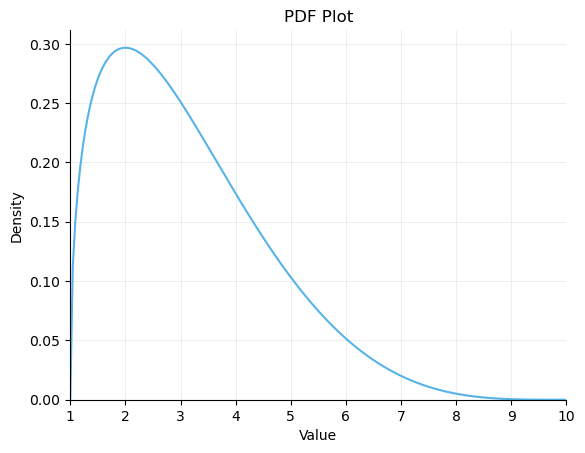

In [6]:
PERT(low=1, mode=2, high=10).plot()

## Plot the CDF

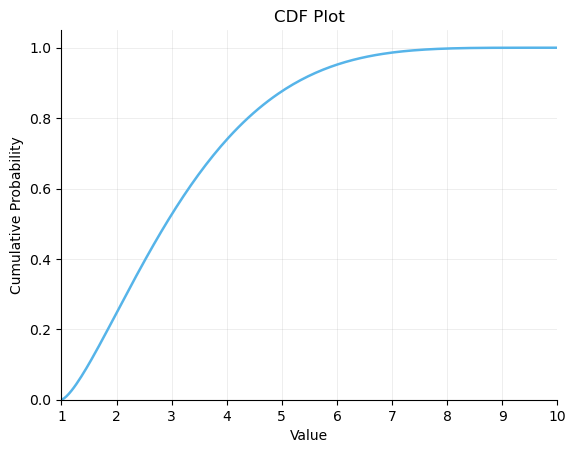

In [7]:
PERT(low=1, mode=2, high=10).plot(cdf=True)

## Simulated values against the theoretical curve

Simulating the random variable and overlaying the pdf shows the two agree.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


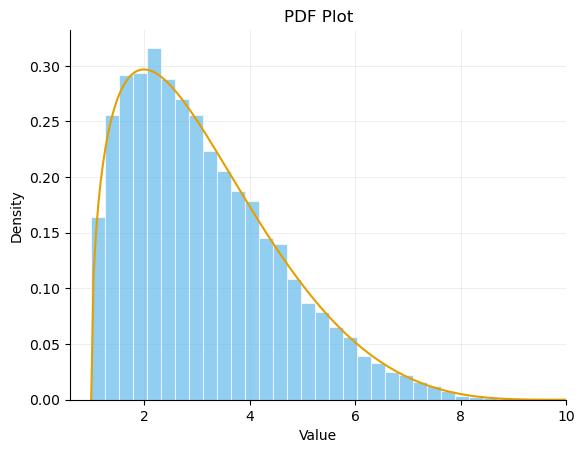

In [8]:
P.sim(10000).plot()
PERT(low=1, mode=2, high=10).plot()

## The `weight` parameter controls how much the mode counts

By default `weight=4`, which gives the standard PERT and the `/ 6` mean formula. In general the mean is `(low + weight * mode + high) / (weight + 2)`, so a larger weight trusts the most likely value more and pulls the distribution in tightly around it.

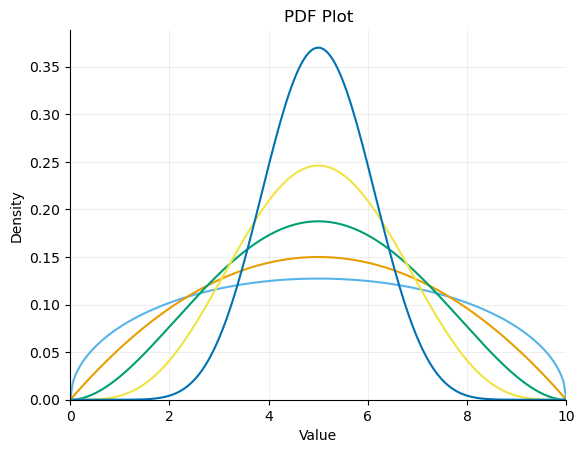

In [9]:
for w in [1, 2, 4, 8, 20]:
    PERT(low=0, mode=5, high=10, weight=w).plot()

## Underneath, a PERT is a stretched beta distribution

The shape parameters are picked so the peak lands exactly on `mode`, then the standard beta on `[0, 1]` is stretched onto `[low, high]`. You can read them off directly.

In [10]:
X = PERT(low=1, mode=2, high=10)
X.alpha, X.beta

(1.4444444444444444, 4.555555555555555)

The clearest case is a symmetric PERT on `[0, 1]`: with the mode in the middle, the shape parameters both come out to 3, so `PERT(0, 0.5, 1)` *is* `Beta(3, 3)`. The two curves land exactly on top of each other.

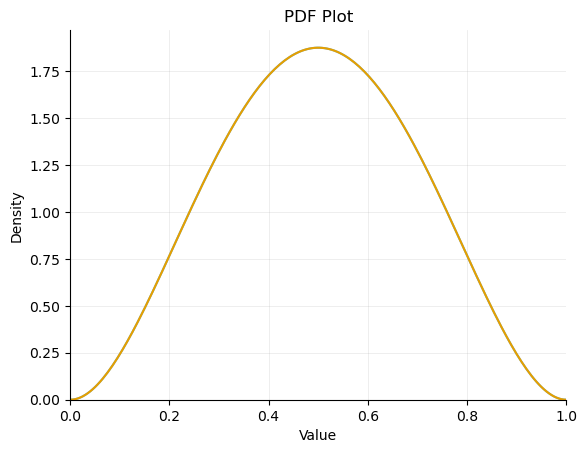

In [11]:
PERT(low=0, mode=0.5, high=1).plot()
Beta(shape1=3, shape2=3).plot()

## Comparison: PERT and Triangular

`Triangular` is the other three-point distribution, and the two make a natural pair. From the same three numbers, the PERT is smooth and concentrated near the mode, while the triangular has a sharp corner there and spreads its weight more evenly toward the extremes. Because the triangular counts the worst case as heavily as the most likely value, its mean sits noticeably higher.

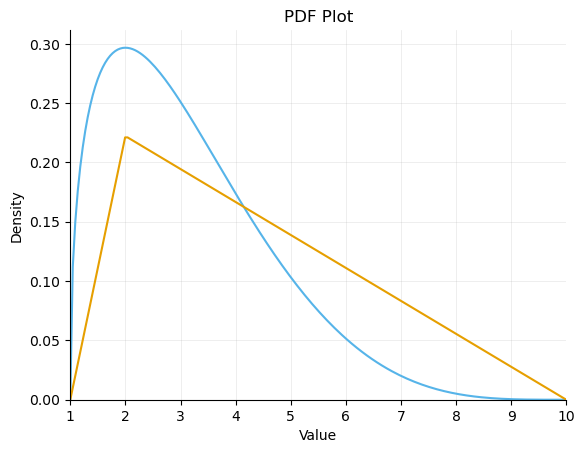

In [12]:
PERT(low=1, mode=2, high=10).plot()
Triangular(low=1, mode=2, high=10).plot()

In [13]:
PERT(low=1, mode=2, high=10).mean(), Triangular(low=1, mode=2, high=10).mean()

(np.float64(3.1666666666666665), np.float64(4.333333333333334))

## The mode may sit at either endpoint

If the most likely case is also the best case (or the worst case), the curve simply slopes one way. Nothing special is needed.

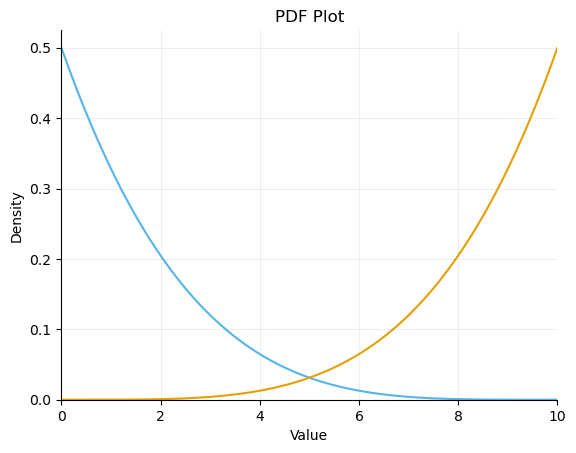

In [14]:
PERT(low=0, mode=0, high=10).plot()
PERT(low=0, mode=10, high=10).plot()